# Mock Exam Airbnb Project by KuanYu HOU ETU20240090

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("AirBnb.csv")
df

,Unnamed: 0,listing_id,id,date,reviewer_id,reviewer_name,comments,Satisfaction_Livel,Satisfaction_Score_5,Recommandation_Score_5,Comeback
0,0,1178162,4724140,2013-05-21,4298113,Olivier,My stay at islam's place was really cool! Good...,Satisfait,3.470052,3.896255,Comeback
1,1,1178162,4869189,2013-05-29,6452964,Charlotte,Great location for both airport and city - gre...,Satisfait,4.000000,2.959623,Comeback
2,2,1178162,5003196,2013-06-06,6449554,Sebastian,We really enjoyed our stay at Islams house. Fr...,Neutre,3.001302,3.443672,No Comeback
3,3,1178162,5150351,2013-06-15,2215611,Marine,The room was nice and clean and so were the co...,Satisfait,3.458333,2.084004,Comeback
4,4,1178162,5171140,2013-06-16,6848427,Andrew,Great location. Just 5 mins walk from the Airp...,Satisfait,3.666667,2.275422,Comeback
...,...,...,...,...,...,...,...,...,...,...,...
68396,68396,8536127,76394660,2016-05-27,72475516,Prakash D,We had smooth check in at Apartment. We were p...,Neutre,3.105417,2.846640,No Comeback
68397,68397,1956275,32160313,2015-05-15,4143054,Amith,Emmanuel was a very good host. Had booked the ...,Satisfait,3.518750,3.583337,Comeback
68398,68398,13062783,98728297,2016-09-01,31264160,Marina,Michael was extremely nice! From picking me up...,Satisfait,3.701389,4.019198,Comeback
68399,68399,798957,11675670,2014-04-11,3033862,Ajev,Ed \r\n\r\nAwesome stay ! Recommended 300% to ...,Très Satisfait,5.000000,4.148623,Comeback


In [4]:
#data infomation
df.shape

(68401, 11)

In [5]:
df.columns

Index(['Unnamed: 0', 'listing_id', 'id', 'date', 'reviewer_id',
       'reviewer_name', 'comments', 'Satisfaction_Livel',
       'Satisfaction_Score_5', 'Recommandation_Score_5', 'Comeback'],
      dtype='object')

In [6]:
# Review df general information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68401 entries, 0 to 68400
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              68401 non-null  int64  
 1   listing_id              68401 non-null  int64  
 2   id                      68401 non-null  int64  
 3   date                    68401 non-null  object 
 4   reviewer_id             68401 non-null  int64  
 5   reviewer_name           68401 non-null  object 
 6   comments                68348 non-null  object 
 7   Satisfaction_Livel      68401 non-null  object 
 8   Satisfaction_Score_5    68401 non-null  float64
 9   Recommandation_Score_5  68401 non-null  float64
 10  Comeback                68401 non-null  object 
dtypes: float64(2), int64(4), object(5)
memory usage: 5.7+ MB


In [7]:
# Review the data and how many rows have missing information in each columns
df.isna().sum()

Unnamed: 0                 0
listing_id                 0
id                         0
date                       0
reviewer_id                0
reviewer_name              0
comments                  53
Satisfaction_Livel         0
Satisfaction_Score_5       0
Recommandation_Score_5     0
Comeback                   0
dtype: int64

In [8]:
# check duplicated data
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)

Empty DataFrame
Columns: [Unnamed: 0, listing_id, id, date, reviewer_id, reviewer_name, comments, Satisfaction_Livel, Satisfaction_Score_5, Recommandation_Score_5, Comeback]
Index: []


## a) Sentiment Analytics
### 1. Extract sentiment: Identify the sentiment of each review (positive, neutral, or negative) and create a sentiment column.

In [10]:
from textblob import TextBlob

In [11]:
def get_sentiment(text):
    # 如果評論為空，則返回 "中立" 
    #pd.isna(text) 判斷 text 是否為空值或缺失值（即 NaN）。若評論是空的，直接返回「Neutral」（中立）情感標籤，避免在空文字上進行情感分析。
    if pd.isna(text):
        return "Neutral"
    # 使用 TextBlob 分析情感得分
    sentiment_score = TextBlob(text).sentiment.polarity
    # 根據得分範圍返回情感標籤
    if sentiment_score > 0.1:
        return "Positive"
    elif sentiment_score < -0.1:
        return "Negative"
    else:
        return "Neutral"

# 對每條評論進行情感分析
df['Sentiment'] = df['comments'].apply(get_sentiment)

In [12]:
df

,Unnamed: 0,listing_id,id,date,reviewer_id,reviewer_name,comments,Satisfaction_Livel,Satisfaction_Score_5,Recommandation_Score_5,Comeback,Sentiment
0,0,1178162,4724140,2013-05-21,4298113,Olivier,My stay at islam's place was really cool! Good...,Satisfait,3.470052,3.896255,Comeback,Positive
1,1,1178162,4869189,2013-05-29,6452964,Charlotte,Great location for both airport and city - gre...,Satisfait,4.000000,2.959623,Comeback,Positive
2,2,1178162,5003196,2013-06-06,6449554,Sebastian,We really enjoyed our stay at Islams house. Fr...,Neutre,3.001302,3.443672,No Comeback,Positive
3,3,1178162,5150351,2013-06-15,2215611,Marine,The room was nice and clean and so were the co...,Satisfait,3.458333,2.084004,Comeback,Positive
4,4,1178162,5171140,2013-06-16,6848427,Andrew,Great location. Just 5 mins walk from the Airp...,Satisfait,3.666667,2.275422,Comeback,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...
68396,68396,8536127,76394660,2016-05-27,72475516,Prakash D,We had smooth check in at Apartment. We were p...,Neutre,3.105417,2.846640,No Comeback,Positive
68397,68397,1956275,32160313,2015-05-15,4143054,Amith,Emmanuel was a very good host. Had booked the ...,Satisfait,3.518750,3.583337,Comeback,Positive
68398,68398,13062783,98728297,2016-09-01,31264160,Marina,Michael was extremely nice! From picking me up...,Satisfait,3.701389,4.019198,Comeback,Positive
68399,68399,798957,11675670,2014-04-11,3033862,Ajev,Ed \r\n\r\nAwesome stay ! Recommended 300% to ...,Très Satisfait,5.000000,4.148623,Comeback,Positive


### 2. Identify recurring keywords: Find frequent keywords in reviews that indicate aspects customers appreciate or dislike.

In [14]:
from collections import Counter
import re
from nltk.corpus import stopwords
import nltk

# 確保下載 nltk 的 stopwords 資料包
nltk.download('stopwords')

# 定義停用詞清單
stop_words = set(stopwords.words('english'))

# 取得所有評論文字，並將它們合併成一個字符串
all_comments = ' '.join(df['comments'].dropna())

# 清理文字：將文字轉為小寫並去除非字母字符
words = re.findall(r'\b\w+\b', all_comments.lower())

# 移除停用詞，只保留有意義的關鍵詞
filtered_words = [word for word in words if word not in stop_words]

# 計算每個詞的出現次數
word_counts = Counter(filtered_words)

# 顯示最常見的20個詞語
print("Top 20 keywords:", word_counts.most_common(20))


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/houguanyu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top 20 keywords: [('great', 40470), ('stay', 35577), ('boston', 32794), ('place', 30467), ('apartment', 28496), ('clean', 23241), ('location', 23086), ('us', 21619), ('room', 20217), ('nice', 19057), ('would', 18955), ('host', 17967), ('comfortable', 16010), ('house', 14563), ('everything', 13914), ('easy', 13147), ('really', 12632), ('recommend', 12496), ('time', 12356), ('well', 11775)]


In [26]:
from collections import Counter
import nltk

# 指定一個明確的下載目錄
nltk.download('punkt', download_dir='C:/Users/cleme/nltk_data')

# 載入必要的 NLP 資料
nltk.download('punkt')

# 定義用來計算最常出現的關鍵字的函數
def get_most_common_keywords(df, sentiment_value):
    # 篩選出指定情感分類的評論
    filtered_comments = df[df['Sentiment'] == sentiment_value]['comments'].dropna()
    
    # 合併所有符合條件的評論
    all_comments = ' '.join(filtered_comments)
    
    # 進行詞彙分割
    words = nltk.word_tokenize(all_comments)
    
    # 計算每個單詞的出現次數
    word_counts = Counter(words)
    
    return word_counts.most_common(10)  # 返回最常見的 10 個詞和它們的出現次數

# 計算正向評論的關鍵字
positive_keywords = get_most_common_keywords(df, 'positive')
print("最常出現的正向評論關鍵字及出現次數:")
print(positive_keywords)

# 計算負向評論的關鍵字
negative_keywords = get_most_common_keywords(df, 'negative')
print("最常出現的負向評論關鍵字及出現次數:")
print(negative_keywords)

最常出現的正向評論關鍵字及出現次數:
[]
最常出現的負向評論關鍵字及出現次數:
[]


[nltk_data] Downloading package punkt to C:/Users/cleme/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt to /Users/houguanyu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Calculate an average sentiment score for each host based on received reviews.

In [28]:
# 首先將情感分數轉換成數值
def sentiment_to_score(sentiment):
    if sentiment == "Positive":
        return 1
    elif sentiment == "Negative":
        return -1
    else:
        return 0

# 新增情感分數欄位
df['Sentiment_Score'] = df['Sentiment'].apply(sentiment_to_score)

# 計算each host的平均情感分數
average_sentiment_score = df.groupby('listing_id')['Sentiment_Score'].mean().reset_index()
print(average_sentiment_score.head())

   listing_id  Sentiment_Score
0        3353         0.852941
1        5506         0.972973
2        6695         0.957447
3        6976         0.951220
4        8792         1.000000


## b) Descriptive Analytics
### 1. Satisfaction analysis: Calculate the mean and median of satisfaction scores and recommendation scores by host and by month.

In [31]:
# 將日期欄位轉換為日期格式
df['date'] = pd.to_datetime(df['date'])

# 從日期中提取月份並新增一個名為 'month' 的欄位
df['month'] = df['date'].dt.month

In [33]:
# 按照 listing_id和 month分組，並計算平均和中位數
satisfaction_stats = df.groupby(['listing_id', 'month'])['Satisfaction_Score_5'].agg(['mean', 'median']).reset_index()
recommendation_stats = df.groupby(['listing_id', 'month'])['Recommandation_Score_5'].agg(['mean', 'median']).reset_index()

# 查看結果
print("Satisfaction Scores by Host and Month:")
print(satisfaction_stats)
print("\nRecommendation Scores by Host and Month:")
print(recommendation_stats)


Satisfaction Scores by Host and Month:
       listing_id  month      mean    median
0            3353      1  3.367508  3.478245
1            3353      2  3.054857  3.033801
2            3353      3  3.241865  3.000000
3            3353      4  3.162599  3.269048
4            3353      5  4.138889  4.138889
...           ...    ...       ...       ...
15194    14813006      9  3.608390  3.608390
15195    14823724      8  3.430903  3.430903
15196    14842237      9  2.500000  2.500000
15197    14843050      9  3.218750  3.218750
15198    14843783      9  3.510648  3.937500

[15199 rows x 4 columns]

Recommendation Scores by Host and Month:
       listing_id  month      mean    median
0            3353      1  2.794849  2.768136
1            3353      2  2.403907  2.234706
2            3353      3  2.721408  2.684539
3            3353      4  3.118977  3.273522
4            3353      5  3.181127  3.181127
...           ...    ...       ...       ...
15194    14813006      9  3.168391  3.

### 2. Customer profile by return intent: Study the characteristics of clients indicating an intention to return (Comeback).

In [36]:
# 客戶檔案分析 - 回訪意圖
comeback_profile = df.groupby('Comeback').describe()
print(comeback_profile)

            Unnamed: 0                                                 \
                 count          mean  min      25%      50%       75%   
Comeback                                                                
Comeback       33935.0  34080.904523  0.0  16913.0  33690.0  51284.50   
No Comeback    34466.0  34317.260634  2.0  17291.5  34705.5  51322.75   

                                   listing_id                ...  \
                 max           std      count          mean  ...   
Comeback                                                     ...   
Comeback     68400.0  19773.825574    33935.0  4.827055e+06  ...   
No Comeback  68396.0  19717.775634    34466.0  4.694632e+06  ...   

            Sentiment_Score              month                                \
                        max       std    count      mean  min  25%  50%  75%   
Comeback                                                                       
Comeback                1.0  0.000000  33935.0  6.791

In [38]:
# 將 'Comeback' 轉換成數值型，1 表示 "Comeback"，0 表示 "No Comeback"
df['Comeback_binary'] = df['Comeback'].apply(lambda x: 1 if x == 'Comeback' else 0)

# 取出相關欄位進行相關性分析
correlation_data = df[['Recommandation_Score_5', 'Satisfaction_Score_5', 'Comeback_binary']]

# 計算相關係數矩陣
correlation_matrix = correlation_data.corr()
correlation_matrix

,Recommandation_Score_5,Satisfaction_Score_5,Comeback_binary
Recommandation_Score_5,1.000000,0.459694,0.342683
Satisfaction_Score_5,0.459694,1.000000,0.750746
Comeback_binary,0.342683,0.750746,1.000000


### 3. Reservation frequency by period: Analyze the frequency of bookings by season or time of year. 

In [41]:
# 將 'date' 欄位轉為日期格式
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 從日期中提取月份和年份
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# 按月份統計預訂頻率
monthly_reservations = df.groupby('month').size()
print(monthly_reservations)

month
1      2121
2      1968
3      3858
4      6125
5      8129
6      8387
7      9349
8     10363
9      5999
10     6106
11     3741
12     2255
dtype: int64


In [43]:
# 定義季節分類
def season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Winter'

# 新增 'season' 欄位
df['season'] = df['month'].apply(season)

# 計算每個季節的預訂頻率
seasonal_reservations = df['season'].value_counts()

print(seasonal_reservations)

season
Summer    28099
Spring    18112
Fall      15846
Winter     6344
Name: count, dtype: int64


### 4. Satisfaction score distribution by host: Compare satisfaction scores across different month, year.

/var/folders/w5/4b9h2mj12mg7pq05x401t0kr0000gn/T/ipykernel_9826/748278151.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=satisfaction_by_host, x='month', y='Satisfaction_Score_5', hue='year', palette='viridis', ci=None)


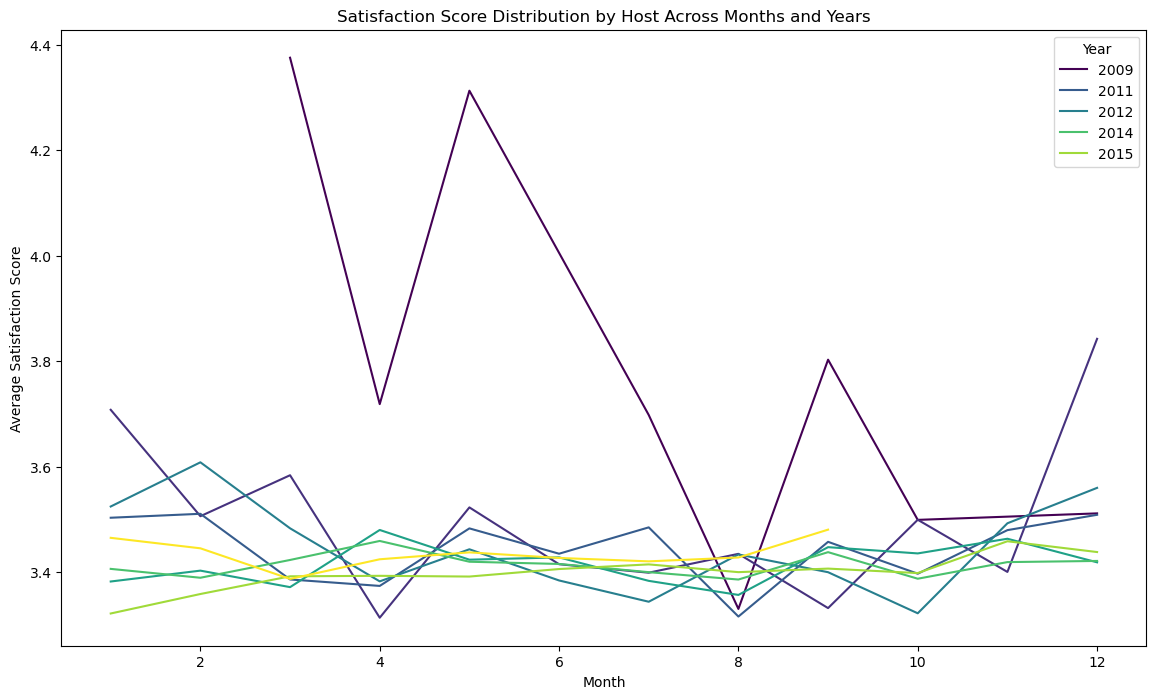

In [46]:
# Convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Extract year and month from the date
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Group by listing_id (host), year, and month to calculate average satisfaction score
satisfaction_by_host = df.groupby(['listing_id', 'year', 'month'])['Satisfaction_Score_5'].mean().reset_index()

# Plot satisfaction score distribution by host across different months and years
plt.figure(figsize=(14, 8))
sns.lineplot(data=satisfaction_by_host, x='month', y='Satisfaction_Score_5', hue='year', palette='viridis', ci=None)
plt.title('Satisfaction Score Distribution by Host Across Months and Years')
plt.xlabel('Month')
plt.ylabel('Average Satisfaction Score')
plt.legend(title='Year')
plt.show()

## c) Visualization Analysis
### 1. Satisfaction and recommendation score charts: Present the distribution of these scores in visual charts.

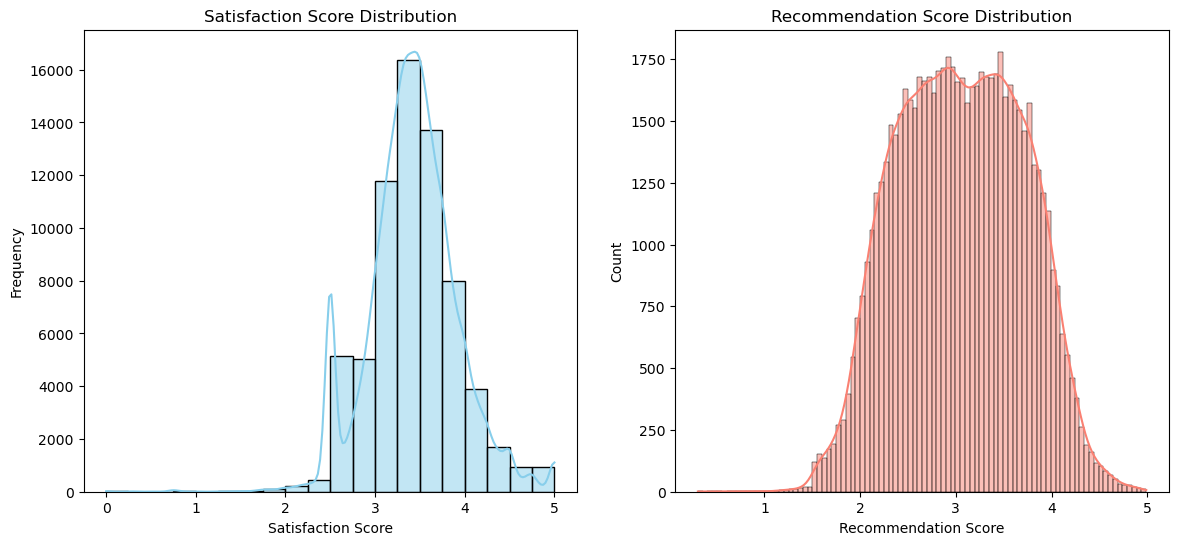

In [48]:
# Distribution of Satisfaction and Recommendation Scores
plt.figure(figsize=(14, 6))

# Satisfaction score distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Satisfaction_Score_5'], bins=20, kde=True, color='skyblue')
plt.title('Satisfaction Score Distribution')
plt.xlabel('Satisfaction Score')
plt.ylabel('Frequency')

# Recommendation score distribution
plt.subplot(1, 2, 2)
sns.histplot(df['Recommandation_Score_5'], kde=True, color='salmon')
plt.title('Recommendation Score Distribution')
plt.xlabel('Recommendation Score')

plt.show()

### 2. Customer return frequency: Use bar or histograms to visualize the number of customers likely to return by year

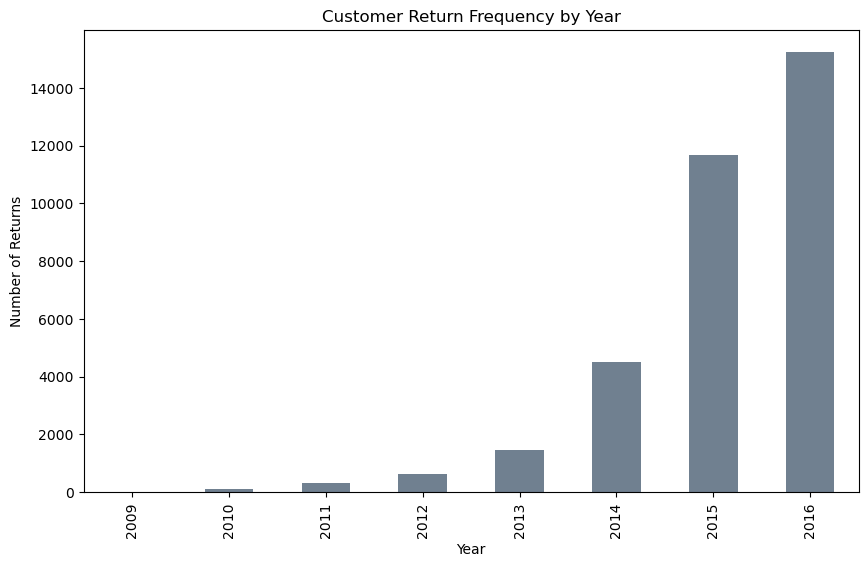

In [51]:
# Convert 'Comeback' to a binary variable for easy plotting
df['Comeback'] = df['Comeback'].apply(lambda x: 1 if x == 'Comeback' else 0)
yearly_return = df.groupby('year')['Comeback'].sum()

# Plot return frequency by year
plt.figure(figsize=(10, 6))
yearly_return.plot(kind='bar', color='#708090')
plt.title('Customer Return Frequency by Year')
plt.xlabel('Year')
plt.ylabel('Number of Returns')
plt.show()

### 3.Booking trends: Create a timeline (by month / year visualization to show peak and low seasons for bookings.

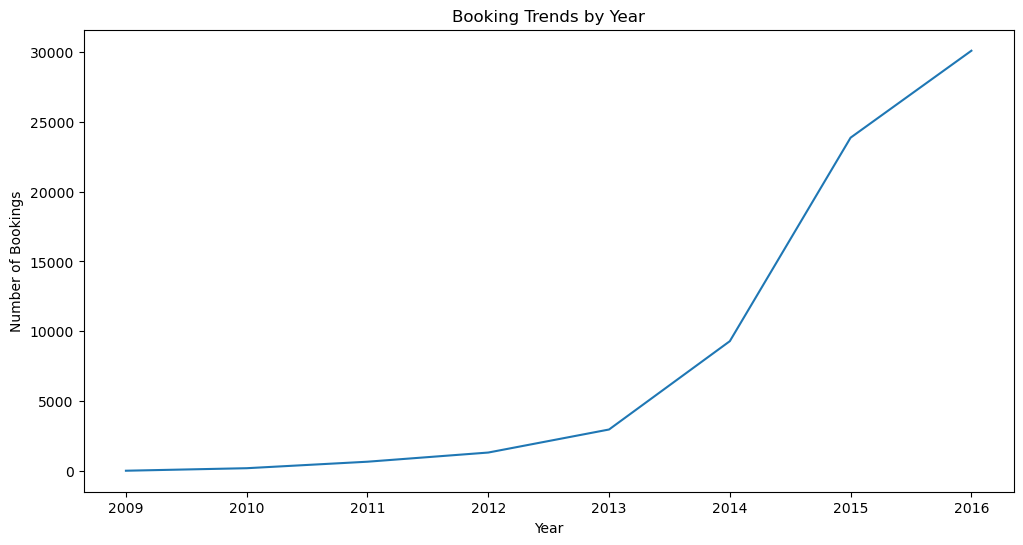

In [55]:
monthly_booking_trends = df.groupby(['year']).size()
monthly_booking_trends.plot(figsize=(12, 6))
plt.title('Booking Trends by Year')
plt.xlabel('Year')
plt.ylabel('Number of Bookings')
plt.show()

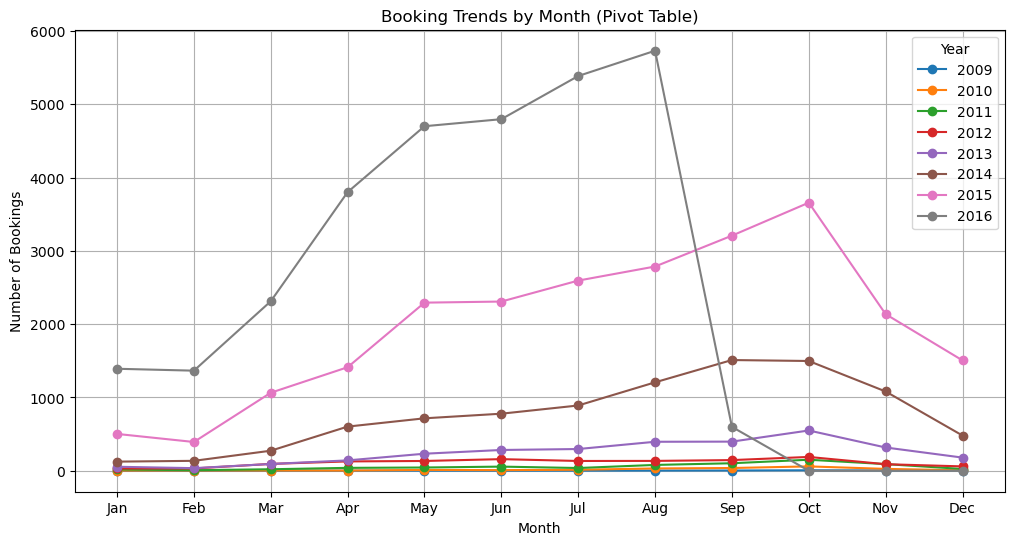

In [57]:
# 將 date 轉換為 datetime 格式
df['date'] = pd.to_datetime(df['date'])

# 提取年份和月份
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# 創建透視表
pivot_table = df.pivot_table(index='month', columns='year', values='date', aggfunc='count', fill_value=0)

# 繪製圖形
plt.figure(figsize=(12, 6))
pivot_table.plot(marker='o', ax=plt.gca())
plt.title('Booking Trends by Month (Pivot Table)')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(ticks=pivot_table.index, labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year')
plt.grid()
plt.show()

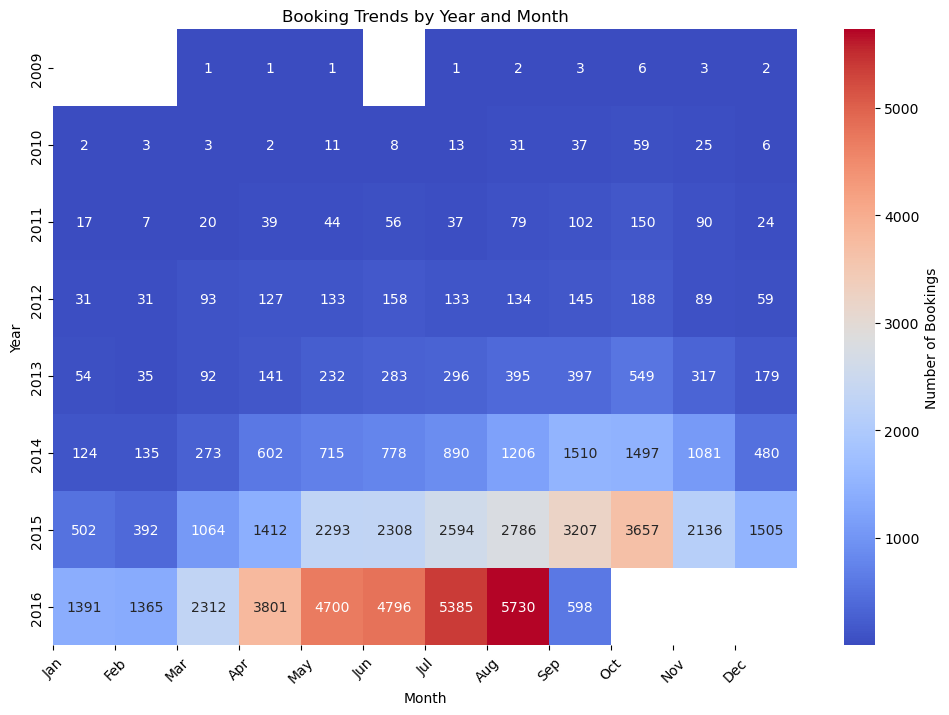

In [59]:
# Convert the 'date' column to datetime format to extract month and year
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month

# Create a pivot table to count the number of bookings by year and month
booking_pivot = df.pivot_table(values='id', index='Year', columns='Month', aggfunc='count')  # assuming 'id' is unique for each booking

# Plot the heatmap for booking trends across months and years
plt.figure(figsize=(12, 8))
sns.heatmap(booking_pivot, annot=True, fmt=".0f", cmap='coolwarm', cbar_kws={'label': 'Number of Bookings'})
plt.title('Booking Trends by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.show()

### 4.Sentiment comparison by host: Present sentiment scores by host to identify the most appreciated hosts.

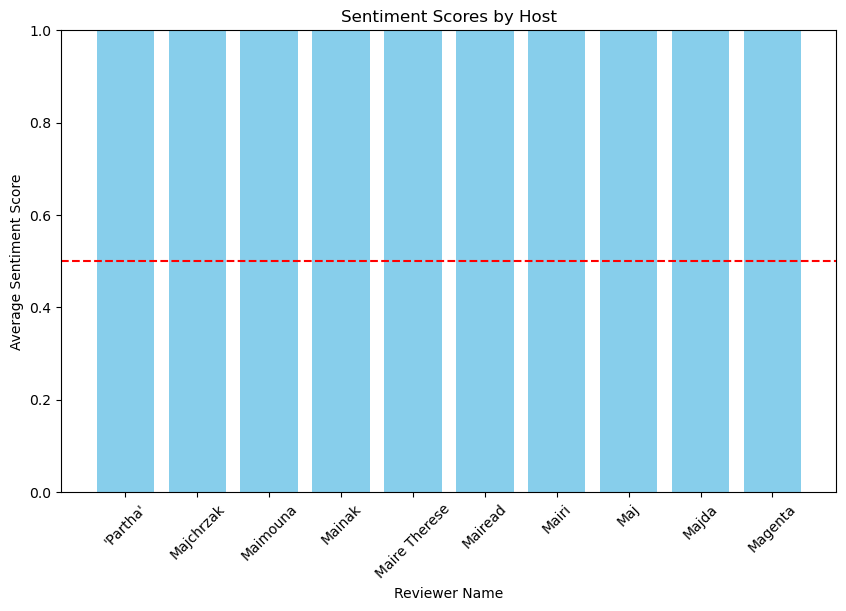

In [62]:
# Group by host and calculate average satisfaction score
host_sentiment = df.groupby('reviewer_name')['Satisfaction_Score_5'].mean().reset_index()

# Define the function sentiment_to_score if not already defined
def sentiment_to_score(satisfaction):
    if satisfaction == 'Satisfait':
        return 1
    elif satisfaction == 'Neutre':
        return 0.5
    else:
        return 0  # Adjust based on sentiment scoring criteria

# Add Sentiment_Score column based on Satisfaction_Livel
df['Sentiment_Score'] = df['Satisfaction_Livel'].apply(sentiment_to_score)

# Calculate average sentiment score per reviewer
host_sentiment = df.groupby('reviewer_name')['Sentiment_Score'].mean().reset_index()

# Sort the hosts by their average sentiment score
host_sentiment = host_sentiment.sort_values(by='Sentiment_Score', ascending=False)

# Display top 10 hosts by average sentiment score
top_hosts = host_sentiment.head(10)

# Plotting the results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(top_hosts['reviewer_name'], top_hosts['Sentiment_Score'], color='skyblue')
plt.xlabel('Reviewer Name')
plt.ylabel('Average Sentiment Score')
plt.title('Sentiment Scores by Host')
plt.xticks(rotation=45)
plt.ylim(0, 1)  # Assuming sentiment scores range from 0 to 1
plt.axhline(y=0.5, color='r', linestyle='--')  # Optional: add a line for average sentiment
plt.show()


## d) Predictive Analytics
### 1. Modeling customer return: Use satisfaction and recommendation scores and others variables to predict the likelihood of customer return (Comeback).

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [66]:
# Encode target variable
df['Comeback'] = df['Comeback'].apply(lambda x: 1 if x == 'Comeback' else 0)

# Select relevant features
features = df[['Satisfaction_Score_5', 'Recommandation_Score_5']]
target = df['Comeback']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Initialize and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[20521]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     20521

    accuracy                           1.00     20521
   macro avg       1.00      1.00      1.00     20521
weighted avg       1.00      1.00      1.00     20521



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:386: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


## 2. Factors affecting satisfaction: Analyze which factors most influence satisfaction scores and Satisfaction_Livel

In [69]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

In [72]:
# Encode categorical variables (if any) to numerical values
# Example: Satisfaction_Livel as a numerical score (Satisfait = 2, Neutre = 1, Not Satisfait = 0)
def satisfaction_to_numeric(satisfaction):
    if satisfaction == 'Satisfait':
        return 2
    elif satisfaction == 'Neutre':
        return 1
    else:
        return 0

df['Satisfaction_Livel_Num'] = df['Satisfaction_Livel'].apply(satisfaction_to_numeric)

# Selecting potential influencing features
features = df[['Satisfaction_Livel_Num', 'Recommandation_Score_5']]  # add more if relevant
target = df['Satisfaction_Score_5']

# Split data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Feature Importance
importance = model.feature_importances_
feature_importance = pd.DataFrame({'Feature': features.columns, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

Mean Squared Error: 0.074947057834735
R2 Score: 0.6976067698324001


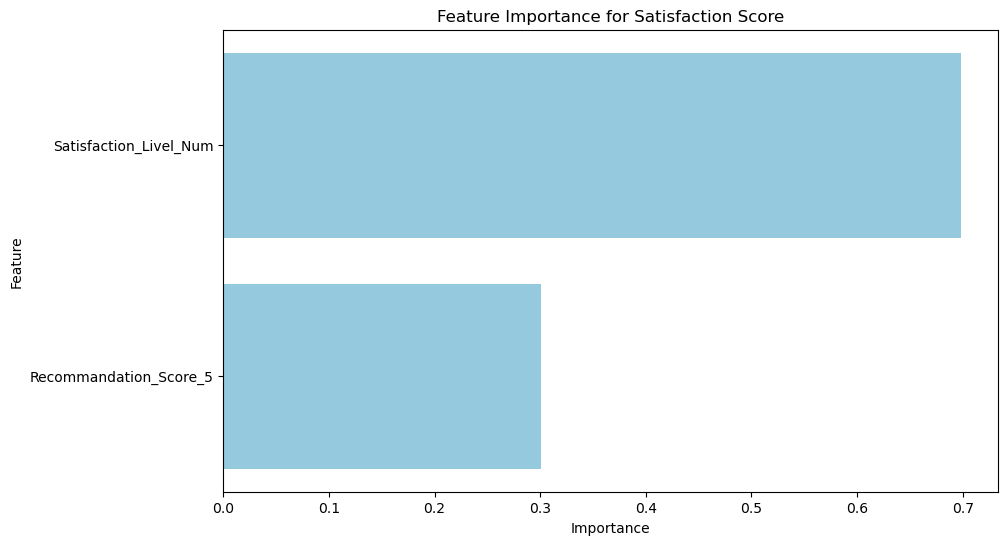

In [73]:
# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, color='skyblue')
plt.title('Feature Importance for Satisfaction Score')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()